# FAKE NEWS DETECTION

## PROBLEM STATEMENT

Fake news detection aims to develop a machine learning system that automatically classifies news articles as either real or fake. The system processes textual content, such as headlines and body text, by cleaning and tokenizing the data, followed by feature extraction. Various machine learning models (e.g., Logistic Regression, Naive Bayes, or deep learning techniques) are trained on labeled datasets containing fake and real news. The model’s performance is evaluated using metrics like accuracy, precision, and recall. The goal is to create a tool that helps identify misinformation, preventing its spread and ensuring more reliable news consumption.

### Importing Libraries

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [139]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Reading CSV

### Data Exploration

In [140]:
data=pd.read_csv('fake_news_data.csv')

In [141]:
data.head()

,text,target
0,When did the decline of coal start? It started...,0
1,"Hillary Clinton agrees with John McCain ""by vo...",1
2,Health care reform legislation is likely to ma...,0
3,The economic turnaround started at the end of ...,0
4,The Chicago Bears have had more starting quart...,1


In [142]:
data.shape


(10239, 2)

In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10239 non-null  object
 1   target  10239 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 160.1+ KB


In [144]:
data.describe()

,target
count,10239.000000
mean,0.355308
std,0.478630
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [145]:
data.isnull().sum()


,0
text,0
target,0


### Outlier Analysis

An outlier is a data point that significantly deviates from the other observations in a dataset. It can distort statistical analyses and models, leading to inaccurate results. Outliers can arise due to errors, variability, or genuine differences in data. In Google Colab, you can detect outliers using statistical methods like Z-scores or the IQR (Interquartile Range) method.

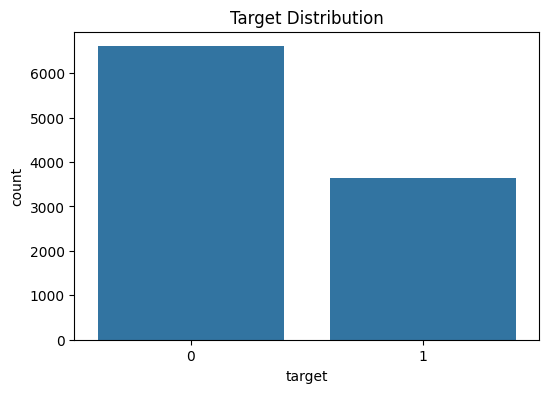

In [146]:
# Bar plot for target column to check distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Target Distribution')
plt.show()


In [147]:
#This function is to handle outliers in text column based on word count
def handle_text_outliers(data, column='text', lower_bound=10, upper_bound=1000):
    #Calculating the word count for each text entry
    data['word_count'] = data[column].apply(lambda x: len(str(x).split()))

    #Filtering out rows where word count is outside the bounds
    data = data[(data['word_count'] >= lower_bound) & (data['word_count'] <= upper_bound)]
    return data.drop(columns=['word_count'])

#This function is to handle outliers in target column (binary classification)
def handle_target_outliers(data, column='target'):
    data =data[data[column].isin([0, 1])]
    return data

#For handling outliers in news column
data=handle_text_outliers(data, lower_bound=10, upper_bound=1000)

#For handle outliers in the target column
data=handle_target_outliers(data)

In [148]:
data.shape

(9100, 2)

### Data Preprocessing

In [149]:
# Convert text column to lowercase
data['text'] = data['text'].str.lower()

# Display the DataFrame
print(data)

                                                    text  target
0      when did the decline of coal start? it started...       0
1      hillary clinton agrees with john mccain "by vo...       1
2      health care reform legislation is likely to ma...       0
3      the economic turnaround started at the end of ...       0
4      the chicago bears have had more starting quart...       1
...                                                  ...     ...
10234  there are a larger number of shark attacks in ...       1
10235  democrats have now become the party of the [at...       1
10236  says an alternative to social security that op...       0
10237  on lifting the u.s. cuban embargo and allowing...       0
10238  the department of veterans affairs has a manua...       0

[9100 rows x 2 columns]


In [150]:
from nltk.tokenize import word_tokenize
# Tokenizing the 'text' column
data['tokens'] = data['text'].apply(word_tokenize)

# Display the DataFrame
print(data['tokens'].head)

<bound method NDFrame.head of 0        [when, did, the, decline, of, coal, start, ?, ...
1        [hillary, clinton, agrees, with, john, mccain,...
2        [health, care, reform, legislation, is, likely...
3        [the, economic, turnaround, started, at, the, ...
4        [the, chicago, bears, have, had, more, startin...
                               ...                        
10234    [there, are, a, larger, number, of, shark, att...
10235    [democrats, have, now, become, the, party, of,...
10236    [says, an, alternative, to, social, security, ...
10237    [on, lifting, the, u.s., cuban, embargo, and, ...
10238    [the, department, of, veterans, affairs, has, ...
Name: tokens, Length: 9100, dtype: object>


In [151]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')

#Defining the stopwords set
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    tokens = word_tokenize(text)  # Tokenize text
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]  # Remove stopwords
    return ' '.join(filtered_tokens)

#Applying stopword removal to the 'text' column
data['text'] = data['text'].apply(remove_stopwords)
data['text']

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text
0,decline coal start ? started natural gas took ...
1,hillary clinton agrees john mccain `` voting g...
2,health care reform legislation likely mandate ...
3,economic turnaround started end term .
4,chicago bears starting quarterbacks last 10 ye...
...,...
10234,larger number shark attacks florida cases vote...
10235,democrats become party [ atlanta ] metro area ...
10236,says alternative social security operates galv...
10237,lifting u.s. cuban embargo allowing travel cuba .


In [152]:
#function to remove punctuations from the text
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

data['text'] = data['text'].apply(remove_punctuation)

In [153]:
import nltk
import pandas as pd
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

#Initializing the stemmer
stemmer = PorterStemmer()
#Applying stemming to each row in 'text' column
def stem_text(text):
    tokens = word_tokenize(text)  # Tokenize the text
    stemmed_words = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return " ".join(stemmed_words)  # Join the words back into a sentence

#Creating a new column with stemmed text
data['stemmed_text'] = data['text'].apply(stem_text)

print(data[['text', 'stemmed_text']])

                                                    text  \
0      decline coal start  started natural gas took s...   
1      hillary clinton agrees john mccain  voting giv...   
2      health care reform legislation likely mandate ...   
3                  economic turnaround started end term    
4      chicago bears starting quarterbacks last 10 ye...   
...                                                  ...   
10234  larger number shark attacks florida cases vote...   
10235  democrats become party  atlanta  metro area bl...   
10236  says alternative social security operates galv...   
10237     lifting us cuban embargo allowing travel cuba    
10238  department veterans affairs manual telling vet...   

                                            stemmed_text  
0      declin coal start start natur ga took start be...  
1      hillari clinton agre john mccain vote give geo...  
2      health care reform legisl like mandat free sex...  
3                       econom turnaround s

In [154]:
import nltk
import pandas as pd
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

# Download necessary resources
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to lemmatize text
def lemmatize_text(text):
    tokens = word_tokenize(text)  # Tokenize text
    lemmatized_words = [lemmatizer.lemmatize(word, wordnet.VERB) for word in tokens]  # Apply lemmatization
    return " ".join(lemmatized_words)  # Reconstruct sentence

# Apply lemmatization to each row in 'text' column
data['text'] = data['text'].apply(lemmatize_text)

# Print the DataFrame
print(data['text'])


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


0        decline coal start start natural gas take star...
1        hillary clinton agree john mccain vote give ge...
2        health care reform legislation likely mandate ...
3                       economic turnaround start end term
4        chicago bear start quarterback last 10 years t...
                               ...                        
10234    larger number shark attack florida case voter ...
10235      democrats become party atlanta metro area black
10236    say alternative social security operate galves...
10237              lift us cuban embargo allow travel cuba
10238    department veterans affairs manual tell vetera...
Name: text, Length: 9100, dtype: object


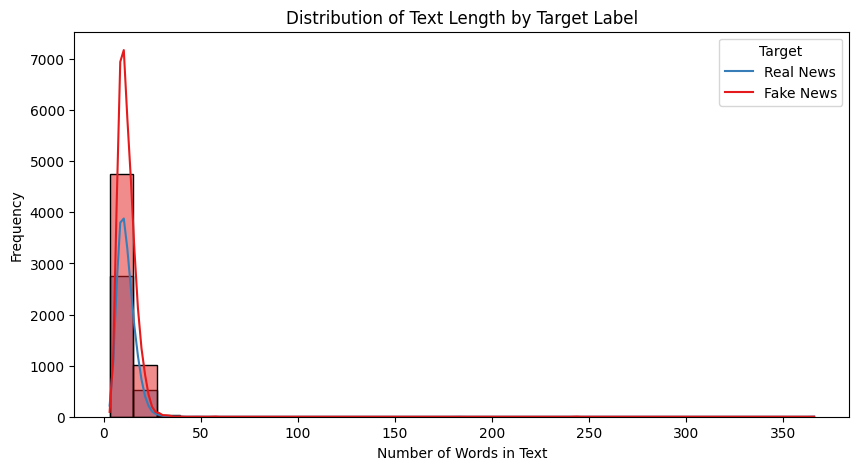

In [155]:
data['text_length'] = data['text'].apply(lambda x: len(str(x).split()))

#Plotting the histogram of text length and target
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='text_length', hue='target', bins=30, kde=True, palette='Set1')

#Labeling and title
plt.xlabel("Number of Words in Text")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length by Target Label")
plt.legend(title="Target", labels=["Real News", "Fake News"])
plt.show()

<ipython-input-156-7671c99a0e17>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=news_counts.index, y=news_counts.values, palette=['red', 'green'])


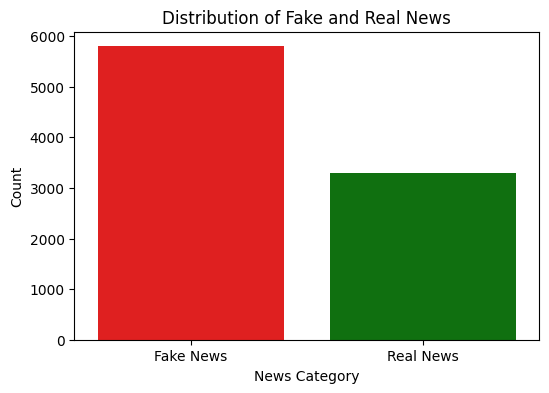

In [156]:
news_counts = data['target'].value_counts()

#Plotting the bar graph
plt.figure(figsize=(6, 4))
sns.barplot(x=news_counts.index, y=news_counts.values, palette=['red', 'green'])

#Labeling and title
plt.xlabel("News Category")
plt.ylabel("Count")
plt.title("Distribution of Fake and Real News")
plt.xticks(ticks=[0, 1], labels=["Fake News", "Real News"])
plt.show()

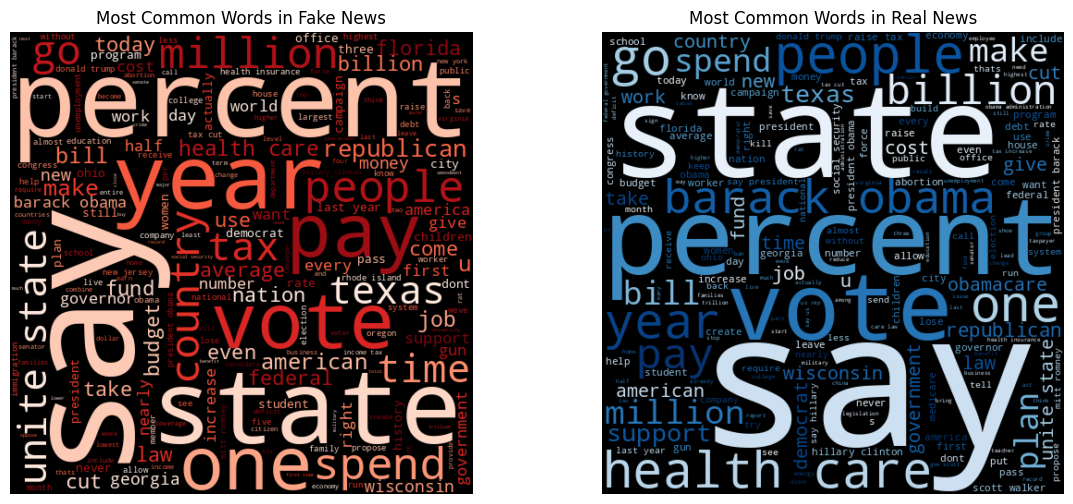

In [157]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#Separating text data based on target labels
fake_news_text = " ".join(data[data['target'] == 1]['text'])
real_news_text = " ".join(data[data['target'] == 0]['text'])

#Generating the Word Clouds of fake and real news
plt.figure(figsize=(14, 6))

#Word Cloud for Fake News
plt.subplot(1, 2, 1)
wordcloud_fake = WordCloud(width=500, height=500, background_color='black', colormap='Reds').generate(fake_news_text)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Fake News")

#Word Cloud for Real News
plt.subplot(1, 2, 2)
wordcloud_real = WordCloud(width=500, height=500, background_color='black', colormap='Blues').generate(real_news_text)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Real News")

plt.show()


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-158-b72a51c11cef>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fake_df['Count'], y=fake_df['Bigram'].apply(lambda x: ' '.join(x)), ax=axes[0], palette="Reds_r")
<ipython-input-158-b72a51c11cef>:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=real_df['Count'], y=real_df['Bigram'].apply(lambda x: ' '.join(x)), ax=axes[1], palette="Blues_r")


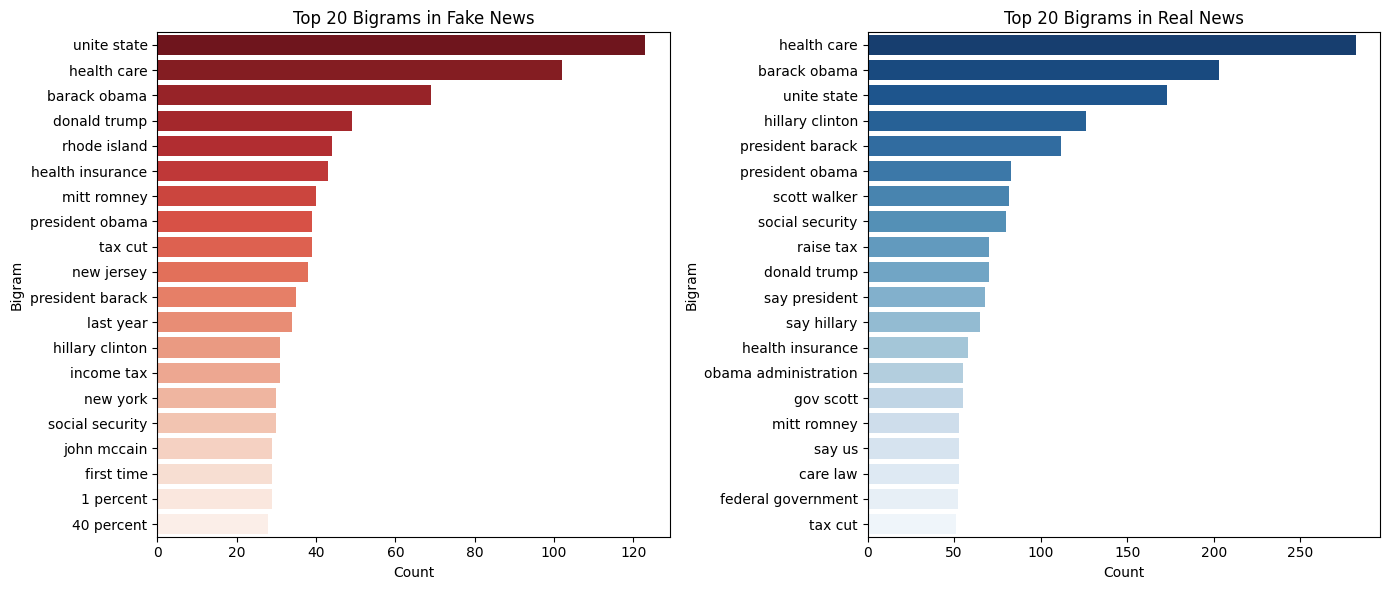

In [158]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Function to clean and tokenize text
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]  # Remove stopwords and non-alphanumeric tokens
    return tokens

# Function to extract top bigrams
def get_top_bigrams(text_data, n=20):
    tokens = preprocess_text(text_data)  # Preprocess and tokenize text
    bigrams = list(ngrams(tokens, 2))  # Generate bigrams
    bigram_counts = Counter(bigrams)  # Count occurrences
    return bigram_counts.most_common(n)

# Ensure 'data' is a DataFrame
if not isinstance(data, pd.DataFrame):
    raise ValueError("Variable 'data' must be a pandas DataFrame")

# Ensure 'text' and 'target' columns exist
if 'text' not in data.columns or 'target' not in data.columns:
    raise ValueError("Columns 'text' and 'target' must exist in the DataFrame")

# Combine text data for fake and real news
fake_text = " ".join(data[data['target'] == 1]['text'].astype(str))
real_text = " ".join(data[data['target'] == 0]['text'].astype(str))

# Get most common bigrams after preprocessing
fake_bigrams = get_top_bigrams(fake_text)
real_bigrams = get_top_bigrams(real_text)

# Convert to DataFrame for visualization
fake_df = pd.DataFrame(fake_bigrams, columns=['Bigram', 'Count'])
real_df = pd.DataFrame(real_bigrams, columns=['Bigram', 'Count'])

# Plot bigram frequencies
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=fake_df['Count'], y=fake_df['Bigram'].apply(lambda x: ' '.join(x)), ax=axes[0], palette="Reds_r")
axes[0].set_title("Top 20 Bigrams in Fake News")

sns.barplot(x=real_df['Count'], y=real_df['Bigram'].apply(lambda x: ' '.join(x)), ax=axes[1], palette="Blues_r")
axes[1].set_title("Top 20 Bigrams in Real News")

plt.tight_layout()
plt.show()


### MODEL TRAINING AND EVALUATION


Model training involves feeding data to a machine learning algorithm to help it learn patterns and make predictions. Evaluation measures the model's performance using metrics like accuracy or precision on unseen data. This helps assess how well the model generalizes and guides improvements for better real-world performance.

In [159]:
from sklearn.model_selection import train_test_split

X=data[['text','tokens','stemmed_text','text_length']]  #defining input features after converting, vectorizing etc
y=data['target']  #target variable

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)  #splitting 80-20 for training/testing

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 7280
Test set size: 1820


### Vectorization of data

The next step after splitting the data is usually to vectorize the text features (like 'text', 'tokens', 'stemmed_text') into numerical format, since machine learning models can't handle raw text directly.

In [160]:
from sklearn.feature_extraction.text import TfidfVectorizer

#initializing tfidf vectorizer
vectorizer=TfidfVectorizer()

#fitting and transforming on training data
X_train_vec=vectorizer.fit_transform(X_train['stemmed_text'])

#transforming test data using same vectorizer
X_test_vec=vectorizer.transform(X_test['stemmed_text'])


### LOGISTIC REGRESSION

In [161]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#initializing and training model
model=LogisticRegression()
model.fit(X_train_vec,y_train)

#predicting on test set
y_pred=model.predict(X_test_vec)

#evaluating performance
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


Accuracy: 0.6368131868131868
              precision    recall  f1-score   support

           0       0.66      0.87      0.75      1153
           1       0.51      0.23      0.32       667

    accuracy                           0.64      1820
   macro avg       0.59      0.55      0.54      1820
weighted avg       0.61      0.64      0.59      1820



Hence we can see the model shows good performance on class 0 but struggles with class 1, indicating class imbalance or model bias.

In [162]:
from imblearn.over_sampling import SMOTE

smote=SMOTE()
X_train_res,y_train_res=smote.fit_resample(X_train_vec,y_train)
model.fit(X_train_res,y_train_res)


LogisticRegression()

We are gain applying Logistic regression

In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#initialize model again (if not already)
model=LogisticRegression()

#train on resampled (balanced) data
model.fit(X_train_res,y_train_res)

#predict on original test set (not resampled)
y_pred=model.predict(X_test_vec)

#evaluate performance
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


Accuracy: 0.6142857142857143
              precision    recall  f1-score   support

           0       0.71      0.67      0.69      1153
           1       0.48      0.52      0.50       667

    accuracy                           0.61      1820
   macro avg       0.59      0.59      0.59      1820
weighted avg       0.62      0.61      0.62      1820



As we can see that’s there is already a clear improvement in recall and F1-score for class 1, which means the model is now catching more of the minority class. The observations are:
1. Class 0 dropped a little in performance, but
2. Class 1 (previously weak) got better recall and balanced F1-score
3. Overall, the model is more balanced.

### Improving the performance:



Using Ensemble Learning

In [164]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(class_weight='balanced',random_state=42)
model.fit(X_train_res,y_train_res)
y_pred=model.predict(X_test_vec)


In [165]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#evaluate model
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))


Accuracy: 0.6302197802197802
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1153
           1       0.49      0.36      0.42       667

    accuracy                           0.63      1820
   macro avg       0.59      0.57      0.57      1820
weighted avg       0.61      0.63      0.61      1820

Confusion Matrix:
 [[907 246]
 [427 240]]


After applying various models to my text classification problem, I observed noticeable differences in performance, especially between Logistic Regression and Random Forest. Initially, Logistic Regression with SMOTE improved the recall for class 1 but still struggled with balance. When I switched to Random Forest with class weights and SMOTE, the overall accuracy slightly improved to around 63.8%, and the precision for class 1 increased. However, the recall for class 1 was still quite low (0.35), meaning the model missed many true positives. The confusion matrix confirmed this, showing a significant number of misclassifications for class 1. This suggests that while Random Forest captured patterns in the majority class well, it still struggled to generalize for the minority class. I realized that further improvements could come from hyperparameter tuning, trying more advanced models like XGBoost, and possibly enhancing the feature set for better class separation.

As a student exploring model improvement, the next logical step is to try XGBoost, a powerful gradient boosting algorithm that often performs better on complex and imbalanced datasets. Since Random Forest gave moderate improvement, XGBoost might better capture subtle patterns, especially in your text-based features.

In [166]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Initialize model with scale_pos_weight to handle class imbalance
xgb_model = xgb.XGBClassifier(scale_pos_weight=len(y_train_res) / sum(y_train_res == 1), random_state=42)

# Fit model on balanced training data
xgb_model.fit(X_train_res, y_train_res)

# Predict on original test set
y_pred_xgb = xgb_model.predict(X_test_vec)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


Accuracy: 0.5302197802197802
              precision    recall  f1-score   support

           0       0.71      0.43      0.54      1153
           1       0.42      0.70      0.52       667

    accuracy                           0.53      1820
   macro avg       0.56      0.57      0.53      1820
weighted avg       0.60      0.53      0.53      1820



After running XGBoost, I noticed that the model's accuracy dropped to ~52.9%, which is lower than before. However, something interesting happened:

  Recall for class 1 (the minority class) jumped up to 0.69, meaning the model correctly identified more instances of class 1 than before.

  But, class 0 performance suffered — its recall dropped to 0.44.

  Precision for class 1 is now only 0.41, indicating a lot of false positives.




This tells me that XGBoost, in its current form, is favoring the minority class too much, possibly because of the high scale_pos_weight value or due to overfitting on the resampled data.

In [167]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Try different values for scale_pos_weight
weights = [1, 2, 3, 5, 10]
for weight in weights:
    print(f"\nTesting with scale_pos_weight = {weight}")

    # Initialize and train the model
    xgb_model = xgb.XGBClassifier(scale_pos_weight=weight, random_state=42)
    xgb_model.fit(X_train_res, y_train_res)

    # Make predictions
    y_pred = xgb_model.predict(X_test_vec)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



Testing with scale_pos_weight = 1
Accuracy: 0.6285714285714286
              precision    recall  f1-score   support

           0       0.67      0.82      0.74      1153
           1       0.49      0.30      0.37       667

    accuracy                           0.63      1820
   macro avg       0.58      0.56      0.55      1820
weighted avg       0.60      0.63      0.60      1820


Testing with scale_pos_weight = 2
Accuracy: 0.5302197802197802
              precision    recall  f1-score   support

           0       0.71      0.43      0.54      1153
           1       0.42      0.70      0.52       667

    accuracy                           0.53      1820
   macro avg       0.56      0.57      0.53      1820
weighted avg       0.60      0.53      0.53      1820


Testing with scale_pos_weight = 3
Accuracy: 0.489010989010989
              precision    recall  f1-score   support

           0       0.74      0.30      0.43      1153
           1       0.40      0.81      0.54   

In [168]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the XGBoost classifier
xgb_model_final = xgb.XGBClassifier(
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False  # Can be safely removed if using latest xgboost
)

# Train the model
xgb_model_final.fit(X_train_res, y_train_res)

# Predict on the test data
y_pred = xgb_model_final.predict(X_test_vec)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:54:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.6285714285714286
              precision    recall  f1-score   support

           0       0.67      0.82      0.74      1153
           1       0.49      0.30      0.37       667

    accuracy                           0.63      1820
   macro avg       0.58      0.56      0.55      1820
weighted avg       0.60      0.63      0.60      1820

Confusion Matrix:
 [[946 207]
 [469 198]]


In [169]:
import joblib

# Save the model to a file

joblib.dump(xgb_model_final, '/content/xgb_model_final.pkl')
joblib.dump(vectorizer, '/content/tfidf_vectorizer.pkl')


['/content/tfidf_vectorizer.pkl']

In [170]:
from google.colab import files

# Download the model file to your local machine
files.download('/content/xgb_model_final.pkl')
files.download('/content/tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>